#Music Tagging with Deep Learning


# Getting Ready

## Preparing The Dataset
We use a subset of the Magnatagatune dataset that consists of 9074 samples with 8 seconds of audio and only 50 genres.

To make your life easier, place them in a directory as below:

```
├── annotations_final.csv
├── waveform
  ├── 1
  ├── ...
  └── d
```

In [1]:
# # Download the label file

# # this is necessary if you encounter an error message ("NotImplementedError: A UTF-8 locale is required. Got ANSI_X3.4-1968")
# import locale
# locale.getpreferredencoding = lambda: "UTF-8"

# !gdown --id 1rNcHc2l6appY2p3VyGD7fxzzSrxPBwrh


In [2]:
# # Download the audio files
# !gdown --id 1zoJpS1-UMYFWx4NM8bgJt5wmBqsZ5_Da

In [3]:
# # uncompress the audio files
# !unzip waveform.zip

## Importing Packages

In [4]:
import warnings
import multiprocessing
warnings.filterwarnings(action='ignore')

import numpy as np
import pandas as pd
import os
import torchaudio
import torch
import torch.nn as nn
from sklearn import metrics

from tqdm.notebook import tqdm
from glob import glob
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau

import IPython.display as ipd

torch.manual_seed(42)
np.random.seed(42)

## Enabling and Testing the GPU

First, you'll need to enable GPUs for the Colab notebook:

- Go to to the Edit menu (수정) → Notebook Settings (노트 설정)
- Select GPU from the Hardware Accelerator (하드웨어 가속기) drop-down

Next, we'll confirm that we can connect to the GPU with PyTorch and check versions of packages:

In [5]:
if not torch.cuda.is_available():
  raise SystemError('GPU device not found!')
print(f'Found GPU at: {torch.cuda.get_device_name()}')
print(f'PyTorch version: {torch.__version__}')
print(f'Torch Audio version: {torchaudio.__version__}')

Found GPU at: NVIDIA GeForce RTX 2080 Ti
PyTorch version: 2.6.0+cu124
Torch Audio version: 2.6.0+cu124


If the cell above throws an error, then you should enable the GPU following the instruction above!

# Data Checking


In [6]:
# use 50 top tags
TAGS = ['guitar','classical', 'slow','techno','strings','drums','electronic','rock',
        'fast','piano','ambient','beat','violin','vocal','synth','female','indian',
        'opera','male','singing','vocals','no vocals','harpsichord','loud','quiet',
        'flute', 'woman', 'male vocal', 'no vocal', 'pop','soft','sitar', 'solo',
        'man', 'classic', 'choir', 'voice', 'new age', 'dance', 'male voice',
        'female vocal', 'beats', 'harp', 'cello', 'no voice', 'weird', 'country',
        'metal', 'female voice', 'choral']

In [7]:
df = pd.read_csv("./annotations_final.csv", sep="\t", index_col=0)
item = df.iloc[0]
item[item != 0] # check annotated tags

classical                                                    1
strings                                                      1
opera                                                        1
violin                                                       1
mp3_path     f/american_bach_soloists-j_s__bach_solo_cantat...
Name: 2, dtype: object

In [8]:
def filter_out_unannotated(df):
    # filter out, un-annnotated dataset
    df_filter =  df[TAGS].sum(axis=1)
    use_id = df_filter[df_filter != 0].index
    df = df.loc[use_id]
    
    return df

<Axes: >

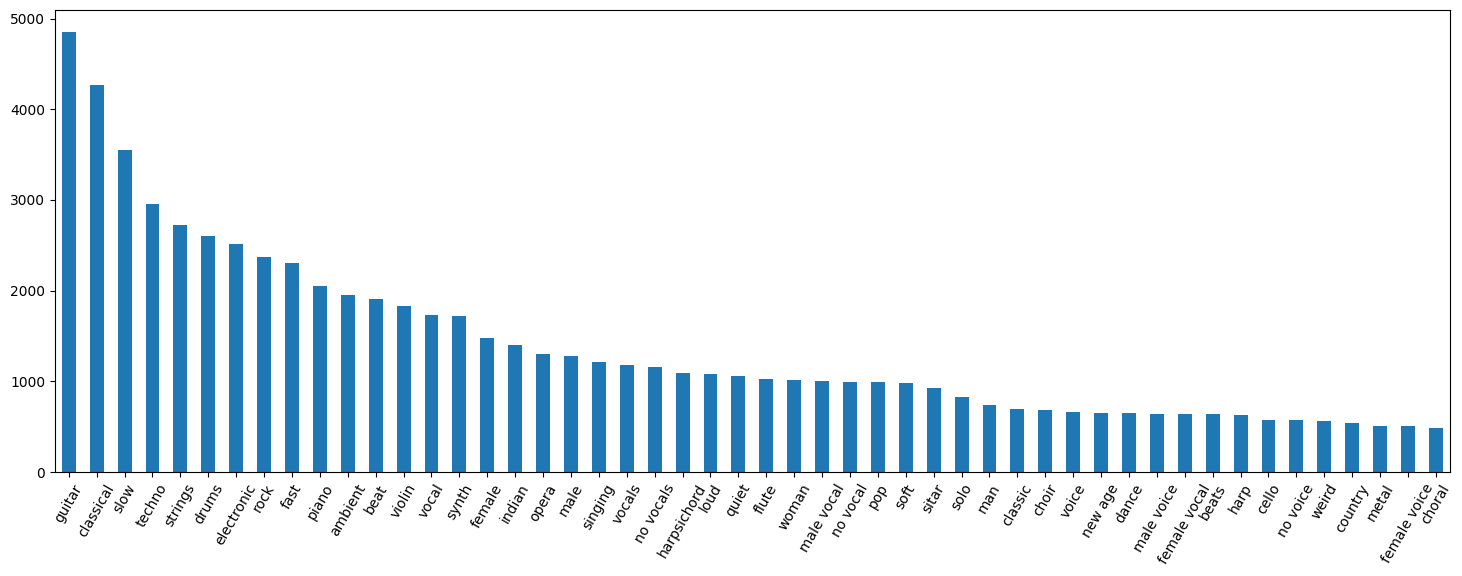

In [9]:
df = filter_out_unannotated(df)
df[TAGS].sum().plot.bar(figsize=(18,6),rot=60) # check data distribution

In [10]:
len(df)

21111

In [11]:
sample_item = df.loc[54327] # sample id
waveform = np.load(os.path.join("./waveform",sample_item['mp3_path'].replace(".mp3",".npy")))
print("annotation tag: ",list(sample_item[sample_item == 1].index))
ipd.Audio(waveform, rate=16000) # load a NumPy array

annotation tag:  ['classical', 'guitar', 'solo', 'strings', 'classical guitar', 'spanish', 'slow']


# Baseline: Training an 1D CNN model from Scratch

This baseline code is provided so that you can easily start the homework and also compare with your own algorithm.
The baseline model extracts mel-spectrogram and has a simple set of 1D CNN model that includes 1D convolutional layers, batch normalization, max-pooling and fully-connected layer.

## Data Preprocessing

In [12]:
def get_split_dict(df):
  split_dict = {'train': [], 'valid': [], 'test': []}
  id_to_path = {}
  assert len(df) != 0
  for idx in range(len(df)):
    item = df.iloc[idx]
    id = item.name
    path = item['mp3_path']
    folder = path.split("/")[0]
    id_to_path[id] = path
    if folder in "012ab":
      split_dict['train'].append(id)# split = "train"
    elif folder == "c":
      split_dict['valid'].append(id)# split = "valid"
    elif folder in "d":
      split_dict['test'].append(id)# split = "test"
  return split_dict, id_to_path

split_dict, id_to_path = get_split_dict(df)

In [13]:
total = len(split_dict['train']) + len(split_dict['valid']) + len(split_dict['test'])
total, len(split_dict['train']) / total, len(split_dict['valid'])/ total, len(split_dict['test'])/ total

(9074, 0.6839321137315406, 0.16850341635441923, 0.14756446991404013)

In [14]:
# df = df[TAGS]

In [15]:
# df_train = df.loc[train]
# df_valid = df.loc[valid]
# df_test = df.loc[test]

In [16]:
# Data processing setup.
SR = 16000
BATCH_SIZE = 16

## Dataset & DataLoader

In [17]:
from torch.utils.data import Dataset, DataLoader
import numpy as np

class AudioDataset(Dataset):
  def __init__(self, paths, input_length, binary, id_to_path, split):
    self.paths = paths
    self.input_length = input_length
    self.binary = binary
    self.id_to_path = id_to_path
    self.split = split

  def __getitem__(self, index):
    item = self.binary.iloc[index]
    waveform = self.item_to_waveform(item)
    return waveform.astype(np.float32), item.values.astype(np.float32)

  def item_to_waveform(self, item):
    id = item.name
    path = os.path.join(self.paths, self.id_to_path[id].replace(".mp3", ".npy")) # pre-extract waveform, for fast loader
    waveform = np.load(path)
    if self.split in ['TRAIN','VALID']:
      random_idx = np.random.randint(low=0, high=int(waveform.shape[0] - self.input_length))
      waveform = waveform[random_idx:random_idx+self.input_length] # extract input
      audio = np.expand_dims(waveform, axis = 0)# 1 x samples
    elif self.split == 'TEST':
      chunk_number = waveform.shape[0] // self.input_length
      chunk = np.zeros((chunk_number, self.input_length))
      for idx in range(chunk.shape[0]):
        chunk[idx] = waveform[idx:idx+self.input_length]
      audio = chunk
    return audio

  def __len__(self):
    return len(self.binary)

### Computing statistics of the training set
The code below compute mean, standard deviation and the minimum temporal dimension size, and use them for preprocessing inputs.

In [18]:
BATCH_SIZE = 16
num_workers = 2
sample_rate = 16000
duration = 3
input_length =  sample_rate * duration
data_path = "./waveform"

In [19]:
def auto_tagging(waveform, model, input_length, tags, topk):
    device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
    model = model.to(device)
    chunk_number = waveform.shape[0] // input_length
    chunk = np.zeros((chunk_number, input_length))
    for idx in range(chunk.shape[0]):
        chunk[idx] = waveform[idx:idx+input_length]
    audio_tensor = torch.from_numpy(chunk.astype(np.float32))
    predictions = model(audio_tensor.unsqueeze(1).to(device))
    logit = predictions.mean(dim=0, keepdim=False).detach().cpu().numpy()
    annotation = [tags[i] for i in logit.argsort()[::-1][:topk]]
    return annotation


class Processor:
    def __init__(self, model, runner, df, split_dict, id_to_path):
        self.model = model
        self.runner = runner
        self.df = df
        self.split_dict = split_dict
        self.id_to_path = id_to_path
        self.load_data()
        
    def load_data(self):
        df_filtered = self.df[TAGS]
        tr_data = AudioDataset(data_path, input_length, df_filtered.loc[self.split_dict['train']], self.id_to_path, 'TRAIN')
        va_data = AudioDataset(data_path, input_length, df_filtered.loc[self.split_dict['valid']], self.id_to_path, 'VALID')
        te_data = AudioDataset(data_path, input_length, df_filtered.loc[self.split_dict['test']], self.id_to_path, 'TEST')
        
        self.loader_train = DataLoader(tr_data, batch_size=BATCH_SIZE, shuffle=True, num_workers=num_workers, drop_last=True)
        self.loader_valid = DataLoader(va_data, batch_size=BATCH_SIZE, shuffle=False, num_workers=num_workers, drop_last=False)
        self.loader_test = DataLoader(te_data, batch_size=1, shuffle=False, num_workers=num_workers, drop_last=False)
        
    def run_process(self, num_epochs):
        # train
        for epoch in range(num_epochs):
            train_loss = self.runner.run(self.loader_train, epoch, 'TRAIN')
            valid_loss = self.runner.run(self.loader_valid, epoch, 'VALID')
            print("[Epoch %d/%d] [Train Loss: %.4f] [Valid Loss: %.4f]" %
                    (epoch + 1, num_epochs, train_loss, valid_loss))
            if self.runner.early_stop(valid_loss, epoch + 1):
                break
            
        # test
        roc_aucs, pr_aucs, epoch_loss, tag_wise_rocaucs = self.runner.test(self.loader_test)
        print(f'test_loss={epoch_loss},  roc_auc={roc_aucs}, pr_auc={pr_aucs}')
        result_auc = pd.DataFrame([tag_wise_rocaucs[tag] for tag in TAGS], columns=['rocauc'], index=TAGS)
        result_auc.sort_values(by='rocauc', ascending=False).plot.bar(figsize=(18,6),rot=60) # which tag is easy and hard task
        
    def sample_inference(self, id):
        waveform = np.load(os.path.join("./waveform", self.id_to_path[id].replace(".mp3",".npy")))
        annotation = auto_tagging(waveform, self.runner.model, input_length, TAGS, 5)
        print("model predict tags: ",annotation)
        
        audio_sample = self.df[TAGS].loc[self.split_dict['test']].loc[id]
        print("annotation tag: ",list(audio_sample[audio_sample != 0].index))
        return ipd.Audio(waveform, rate=16000) # load a NumPy array

## Training the 1D CNN model
The table below shows the architecture of the baseline model

| Layer          | Output Size | Details                 |
|----------------|-------------|-------------------------|
| input          | B x 1 x 16000 * sec,    | batch x channel x samples |
| mel_spec       | B x 96 x 188    | batch x freq x time|
| conv + maxpool | B x 32 x 64    | kernel_size=3, stride=1 |
| conv + maxpool | B x 32 x 22    | kernel_size=3, stride=1 |
| conv + maxpool | B x 32 x 8     | kernel_size=3 stride=1 |
| global_avgpool | B x 32 x 1     | -                       |
| classifier     | B x 50         | -                       |



The folloing code implements the baseline model in PyTorch

In [20]:
import torch.nn as nn

class Baseline(nn.Module):
    def __init__(self,
                sample_rate=16000,
                n_fft=512,
                f_min=0.0,
                f_max=8000.0,
                n_mels=96,
                n_class=50):
        super(Baseline, self).__init__()

        # Spectrogram
        self.spec = torchaudio.transforms.MelSpectrogram(sample_rate=sample_rate,
                                                         n_fft=n_fft,
                                                         f_min=f_min,
                                                         f_max=f_max,
                                                         n_mels=n_mels)
        self.to_db = torchaudio.transforms.AmplitudeToDB()
        self.spec_bn = nn.BatchNorm2d(1)

        self.conv0 = nn.Sequential(
            nn.Conv1d(n_mels, out_channels=32, kernel_size=3, stride=1, padding=3),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=3, stride=3)
            )

        self.conv1 = nn.Sequential(
            nn.Conv1d(32, out_channels=32, kernel_size=3, stride=1, padding=3),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=3, stride=3)
            )

        self.conv2 = nn.Sequential(
            nn.Conv1d(32, out_channels=32, kernel_size=3, stride=1, padding=3),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=3, stride=3)
            )
        # Aggregate features over temporal dimension.
        self.final_pool = nn.AdaptiveAvgPool1d(1)
        # Predict tag using the aggregated features.
        self.linear = nn.Linear(32, n_class)

    def forward(self, x):
        x = self.spec(x)
        x = self.to_db(x)
        x = self.spec_bn(x)
        x = x.squeeze(1) # for 1D conv
        x = self.conv0(x)
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.final_pool(x)
        x = self.linear(x.squeeze(-1))
        x = nn.Sigmoid()(x) # for binary cross entropy loss
        return x

In [21]:
class Runner(object):
  def __init__(self, model, lr, momentum, weight_decay, sr, tags):
    self.optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=momentum, nesterov=True, weight_decay=weight_decay)
    self.scheduler = ReduceLROnPlateau(self.optimizer, mode='min', factor=0.2, patience=5, verbose=True)
    self.learning_rate = lr
    self.stopping_rate = sr
    self.device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
    self.model = model.to(self.device)
    self.criterion = torch.nn.BCELoss().to(self.device)
    self.tags = tags

  # Running model for train, test and validation. mode: 'train' for training, 'eval' for validation and test
  def run(self, dataloader, epoch, mode='TRAIN'):
    self.model.train() if mode is 'TRAIN' else self.model.eval()

    epoch_loss = 0
    pbar = tqdm(dataloader, desc=f'{mode} Epoch {epoch:02}')  # progress bar
    for x, y in pbar:
      # Move mini-batch to the desired device.
      x = x.to(self.device)
      y = y.to(self.device)
      # Feed forward the model.
      prediction = self.model(x)
      # Compute the loss.
      loss = self.criterion(prediction, y)
      if mode is 'TRAIN':
        # Perform backward propagation to compute gradients.
        loss.backward()
        # Update the parameters.
        self.optimizer.step()
        # Reset the computed gradients.
        self.optimizer.zero_grad()

      batch_size = len(x)
      epoch_loss += batch_size * loss.item()
    epoch_loss = epoch_loss / len(dataloader.dataset)
    return epoch_loss

  def test(self, dataloader):
    self.model.eval()
    epoch_loss = 0
    predictions = []
    labels = []
    pbar = tqdm(dataloader, desc=f'TEST')  # progress bar
    for x, y in pbar:
      x = x.to(self.device)
      y = y.to(self.device)
      x = x.transpose(1,0) # pre-batch in audio loader (chunk, 1, waveform)
      prediction = self.model(x)
      prediction = prediction.mean(dim=0, keepdim=True) # average chunk audio
      loss = self.criterion(prediction, y)
      batch_size = len(x)
      epoch_loss += batch_size * loss.item()
      predictions.extend(prediction.detach().cpu().numpy())
      labels.extend(y.detach().cpu().numpy())
    epoch_loss = epoch_loss / len(dataloader.dataset)
    roc_aucs, pr_aucs, tag_wise_rocaucs = self.get_auc(predictions, labels)
    return roc_aucs, pr_aucs, epoch_loss, tag_wise_rocaucs

  # Early stopping function for given validation loss
  def early_stop(self, loss, epoch):
    self.scheduler.step(loss, epoch)
    self.learning_rate = self.optimizer.param_groups[0]['lr']
    stop = self.learning_rate < self.stopping_rate
    return stop

  def get_auc(self, predictions, labels):
    roc_aucs = metrics.roc_auc_score(labels, predictions, average='macro')
    pr_aucs = metrics.average_precision_score(labels, predictions, average='macro')
    tag_wise_predictions = np.stack(predictions).T
    tag_wise_labels = np.stack(labels).T
    tag_wise_rocaucs = {}
    for tag, logit, label in zip(self.tags, tag_wise_predictions, tag_wise_labels):
      tag_wise_rocaucs[tag] = metrics.roc_auc_score(label, logit)
    return roc_aucs, pr_aucs, tag_wise_rocaucs

In [22]:
# Training setup.
LR = 1e-3  # learning rate
SR = 1e-5  # stopping rate
MOMENTUM = 0.9
NUM_EPOCHS = 10 # increase the epoch for your experiment
WEIGHT_DECAY = 0.0  # L2 regularization weight

TRAIN Epoch 00:   0%|          | 0/387 [00:00<?, ?it/s]

VALID Epoch 00:   0%|          | 0/96 [00:00<?, ?it/s]

[Epoch 1/10] [Train Loss: 0.6191] [Valid Loss: 0.5173]


TRAIN Epoch 01:   0%|          | 0/387 [00:00<?, ?it/s]

VALID Epoch 01:   0%|          | 0/96 [00:00<?, ?it/s]

...

TRAIN Epoch 09:   0%|          | 0/387 [00:00<?, ?it/s]

VALID Epoch 09:   0%|          | 0/96 [00:00<?, ?it/s]

[Epoch 10/10] [Train Loss: 0.2226] [Valid Loss: 0.2216]


TEST:   0%|          | 0/1339 [00:00<?, ?it/s]

test_loss=0.44119128833028964,  roc_auc=0.6008829489654212, pr_auc=0.1302318333458118


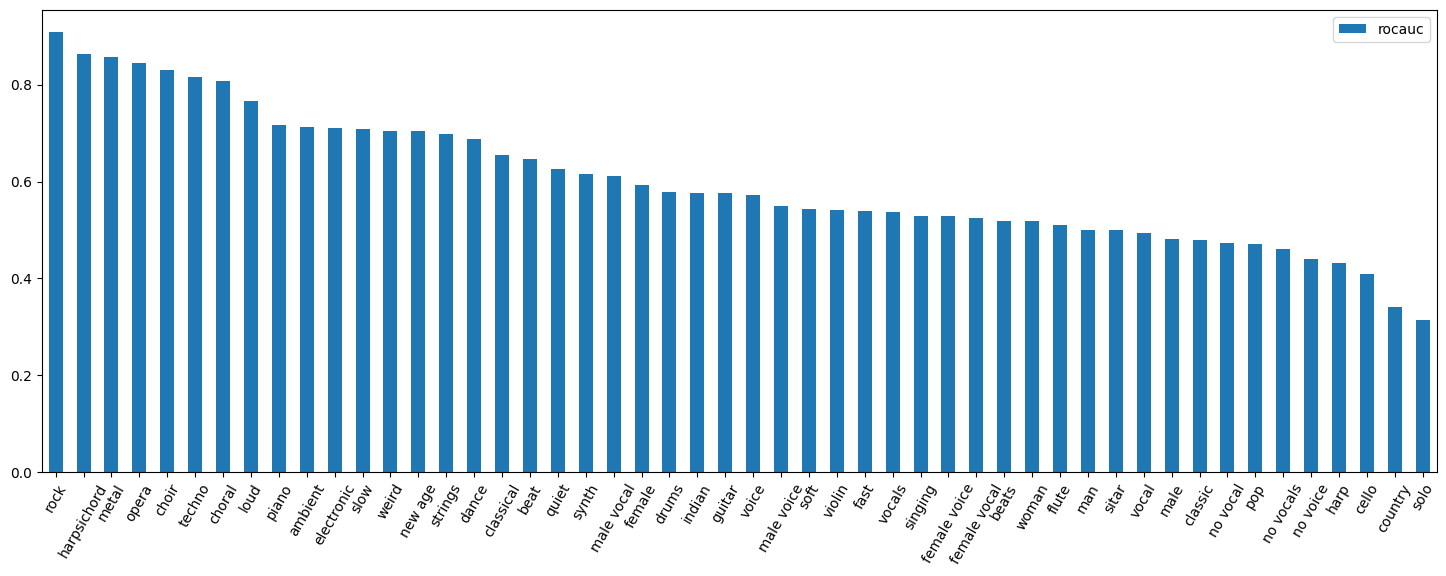

In [23]:
# Iterate over epochs.
model = Baseline()
runner = Runner(model=model, lr = LR, momentum = MOMENTUM, weight_decay = WEIGHT_DECAY, sr = SR, tags=TAGS)

conv1d_baseline_processor = Processor(model, runner, df, split_dict, id_to_path)
conv1d_baseline_processor.run_process(num_epochs=NUM_EPOCHS)

In [24]:
conv1d_baseline_processor.sample_inference(234)

model predict tags:  ['classical', 'guitar', 'techno', 'electronic', 'drums']
annotation tag:  ['guitar', 'techno', 'rock', 'fast', 'synth']


## [Question 1] Implement a 2D CNN architecture.
Implement a 2D CNN with the folloing configuration.

| Layer          | Output Size | Details                 |
|----------------|-------------|-------------------------|
| input          | B x 1 x sample_rate * duration,    | batch x channel (mono) x samples |
| mel_spec       | B x 1 x 96 x 188    | batch x channel (mono) x freq x time|
| conv + maxpool | B x 64 x 24 x 47    | output_channels=64, kernel_size=3, pooling=(4,4) |
| conv + maxpool | B x 128 x 8 x 15    | output_channels=128, kernel_size=3, pooling=(3,3) |
| conv + maxpool | B x 128 x  2 x 5     | output_channels=128, kernel_size=3 pooling=(3,3) |
| conv + maxpool | B x 64 x 1 x 1      | output_channels=64, kernel_size=3 pooling=(2,5)                    |
| classifier     | B x 50         | -                       |


Note: you should give appropriate paddings!

The folowing is the startup code. Fill in the "to-do" area.

In [25]:
import torch.nn as nn

class Conv_2d(nn.Module):
    def __init__(self, input_channels, output_channels, kernel_size=3, stride=1, padding=1, pooling=2):
        super(Conv_2d, self).__init__()
        # To do
        #========================================
        self.conv = nn.Conv2d(input_channels, output_channels, kernel_size=kernel_size, stride=stride, padding=padding)
        self.bn = nn.BatchNorm2d(output_channels)
        self.relu = nn.ReLU()
        self.mp = nn.MaxPool2d(kernel_size=pooling)
        
    def forward(self, x):
        out = self.conv(x)
        out = self.bn(out)
        out = self.relu(out)
        out = self.mp(out)
        return out
    #========================================

class CNN2D(nn.Module):
    def __init__(self,
                sample_rate=16000,
                n_fft=512,
                f_min=0.0,
                f_max=8000.0,
                n_mels=96,
                n_class=50):
        super(CNN2D, self).__init__()

        # Spectrogram
        self.spec = torchaudio.transforms.MelSpectrogram(sample_rate=sample_rate,
                                                         n_fft=n_fft,
                                                         f_min=f_min,
                                                         f_max=f_max,
                                                         n_mels=n_mels)
        self.to_db = torchaudio.transforms.AmplitudeToDB()
        self.spec_bn = nn.BatchNorm2d(1)
        # To do
        #========================================
        self.layer1 = Conv_2d(input_channels=1, output_channels=64, kernel_size=3, stride=1, padding=1, pooling=(4, 4))
        self.layer2 = Conv_2d(input_channels=64, output_channels=128, kernel_size=3, stride=1, padding=1, pooling=(3, 3))
        self.layer3 = Conv_2d(input_channels=128, output_channels=128, kernel_size=3, stride=1, padding=1, pooling=(3, 3))
        self.layer4 = Conv_2d(input_channels=128, output_channels=64, kernel_size=3, stride=1, padding=1, pooling=(2, 5))
        #========================================
        self.linear = nn.Linear(64, n_class)
    def forward(self, x):
        x = self.spec(x)
        x = self.to_db(x)
        x = self.spec_bn(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = x.view(x.size(0), -1)
        x = self.linear(x)
        x = nn.Sigmoid()(x) # for binary cross entropy loss
        return x

TRAIN Epoch 00:   0%|          | 0/387 [00:00<?, ?it/s]

VALID Epoch 00:   0%|          | 0/96 [00:00<?, ?it/s]

[Epoch 1/10] [Train Loss: 0.3184] [Valid Loss: 0.2233]


TRAIN Epoch 01:   0%|          | 0/387 [00:00<?, ?it/s]

VALID Epoch 01:   0%|          | 0/96 [00:00<?, ?it/s]

...

TRAIN Epoch 09:   0%|          | 0/387 [00:00<?, ?it/s]

VALID Epoch 09:   0%|          | 0/96 [00:00<?, ?it/s]

[Epoch 10/10] [Train Loss: 0.1891] [Valid Loss: 0.1893]


TEST:   0%|          | 0/1339 [00:00<?, ?it/s]

test_loss=0.3802391654680343,  roc_auc=0.762326481467667, pr_auc=0.24810959996529244


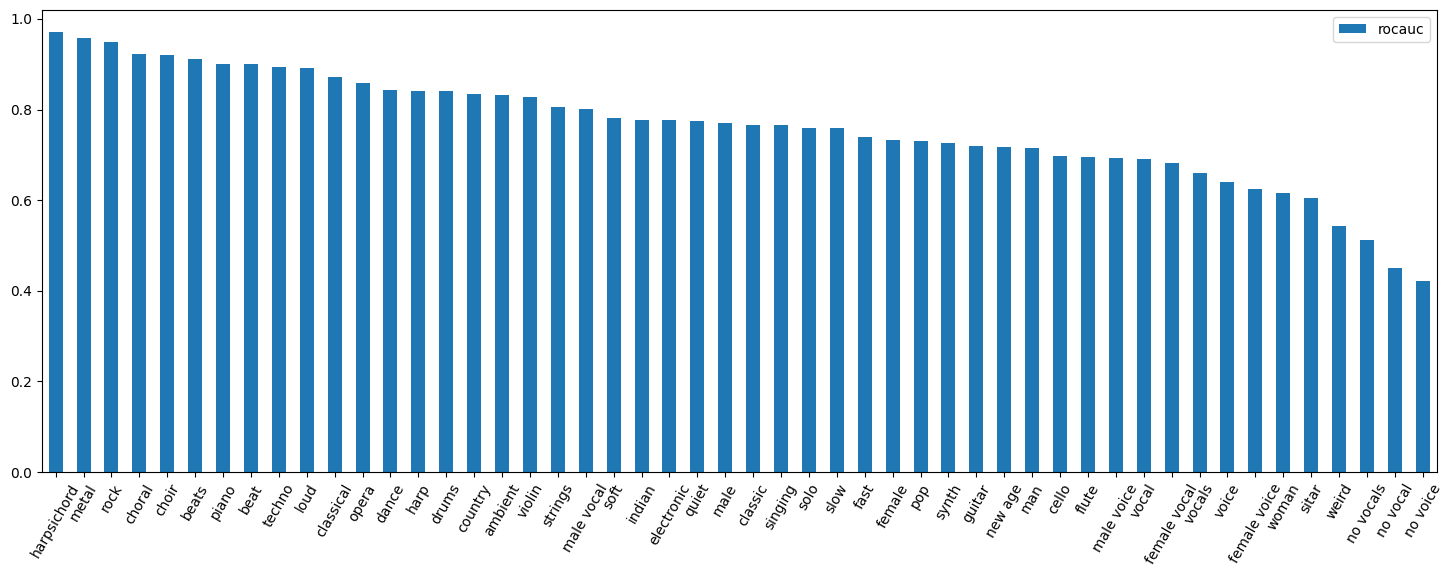

In [26]:
# Iterate over epochs.
model = CNN2D()
runner = Runner(model=model, lr = LR, momentum = MOMENTUM, weight_decay = WEIGHT_DECAY, sr = SR, tags=TAGS)

conv2d_baseline_processor = Processor(model, runner, df, split_dict, id_to_path)
conv2d_baseline_processor.run_process(num_epochs=NUM_EPOCHS)

## [Question 2] Improve the performenace.
Now it is your turn. You can improve the model performance with your own idea.

In [27]:
import torch
import torch.nn as nn
import torchaudio

class HybridAttentionCNN(nn.Module):
    def __init__(self,
                 sample_rate=16000,
                 n_fft=512,
                 f_min=0.0,
                 f_max=8000.0,
                 n_mels=96,
                 n_class=50):
        super(HybridAttentionCNN, self).__init__()
        
        # Spectrogram frontend
        self.spec = torchaudio.transforms.MelSpectrogram(
            sample_rate=sample_rate,
            n_fft=n_fft,
            f_min=f_min,
            f_max=f_max,
            n_mels=n_mels
        )
        self.to_db = torchaudio.transforms.AmplitudeToDB()
        self.spec_bn = nn.BatchNorm2d(1)

        # 2D Conv layers
        self.conv2d = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d((2, 2)),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d((2, 2)),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
        )

        # Convert to sequence for 1D conv
        self.temporal_conv = nn.Sequential(
            nn.Conv1d(256 * 24, 512, kernel_size=5, padding=2),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.MaxPool1d(3, stride=3)
        )

        # Attention block
        self.attn = nn.Sequential(
            nn.Linear(512, 128),
            nn.Tanh(),
            nn.Linear(128, 1)
        )

        self.final_pool = nn.AdaptiveAvgPool1d(1)
        self.classifier = nn.Linear(512, n_class)

    def forward(self, x):
        x = self.spec(x)
        x = self.to_db(x)
        x = self.spec_bn(x)  # (B, 1, 96, T)

        x = self.conv2d(x)   # (B, 256, H, W)
        b, c, h, w = x.shape
        x = x.view(b, c * h, w)  # (B, C*H, T)

        x = self.temporal_conv(x)  # (B, 512, T')
        
        # Attention mechanism over time
        x_perm = x.permute(0, 2, 1)  # (B, T', 512)
        weights = self.attn(x_perm)  # (B, T', 1)
        weights = torch.softmax(weights.squeeze(-1), dim=1).unsqueeze(-1)  # (B, T', 1)

        x_attn = (x_perm * weights).sum(dim=1)  # (B, 512)

        out = self.classifier(x_attn)
        return torch.sigmoid(out)

TRAIN Epoch 00:   0%|          | 0/387 [00:00<?, ?it/s]

VALID Epoch 00:   0%|          | 0/96 [00:00<?, ?it/s]

[Epoch 1/10] [Train Loss: 0.2446] [Valid Loss: 0.1955]


TRAIN Epoch 01:   0%|          | 0/387 [00:00<?, ?it/s]

VALID Epoch 01:   0%|          | 0/96 [00:00<?, ?it/s]

...

TRAIN Epoch 09:   0%|          | 0/387 [00:00<?, ?it/s]

VALID Epoch 09:   0%|          | 0/96 [00:00<?, ?it/s]

[Epoch 10/10] [Train Loss: 0.1654] [Valid Loss: 0.1698]


TEST:   0%|          | 0/1339 [00:00<?, ?it/s]

test_loss=0.35514034934013616,  roc_auc=0.8112031206407311, pr_auc=0.2874613517801656


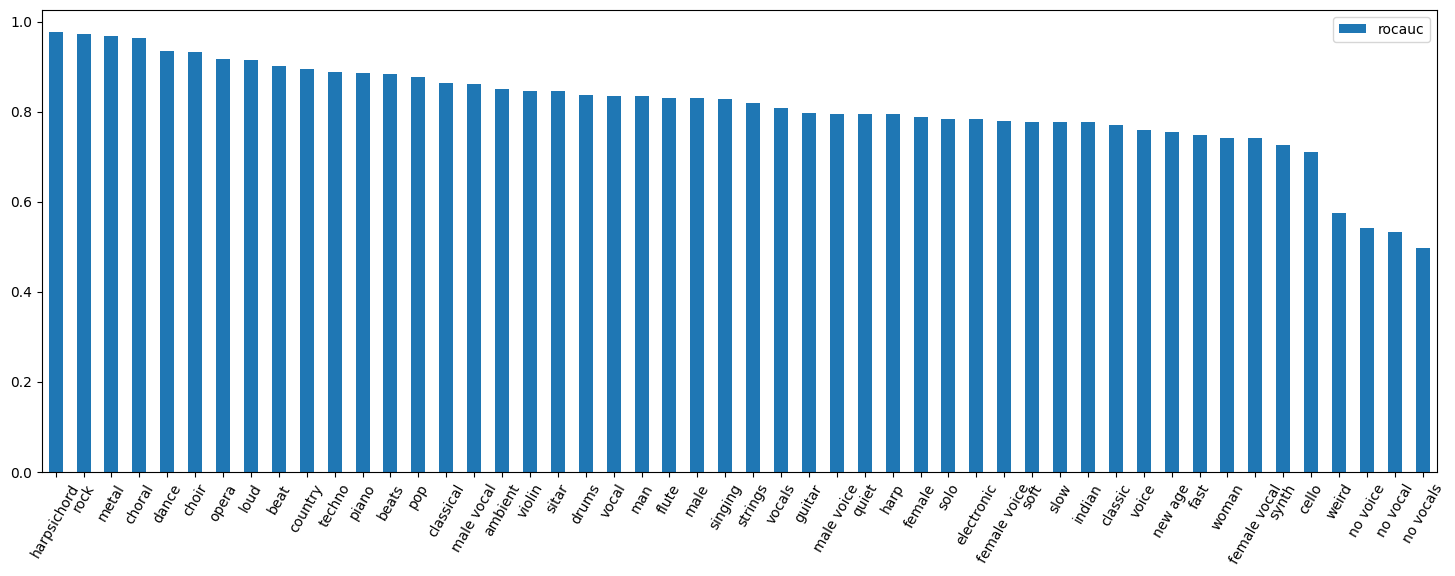

In [28]:
# Iterate over epochs.
model = HybridAttentionCNN()
runner = Runner(model=model, lr = LR, momentum = MOMENTUM, weight_decay = WEIGHT_DECAY, sr = SR, tags=TAGS)

mymodel_processor = Processor(model, runner, df, split_dict, id_to_path)
mymodel_processor.run_process(num_epochs=NUM_EPOCHS)

# Refine the labels

In [29]:
df_new = pd.read_csv("./annotations_final.csv", sep="\t", index_col=0)
list(set(df_new.columns) - set(TAGS))

['electric guitar',
 'reggae',
 'rap',
 'middle eastern',
 'modern',
 'trumpet',
 'no drums',
 'percussion',
 'women',
 'no voices',
 'spacey',
 'folk',
 'synthesizer',
 'english',
 'plucking',
 'sax',
 'oriental',
 'hip hop',
 'bongos',
 'violins',
 'quick',
 'light',
 'drone',
 'medieval',
 'male singer',
 'dark',
 'jungle',
 'male vocals',
 'not rock',
 'not classical',
 'fiddle',
 'drum',
 'electronica',
 'female vocals',
 'guitars',
 'house',
 'foreign',
 'female singing',
 'no singer',
 'old',
 'lol',
 'electro',
 'silence',
 'bells',
 'monks',
 'hard',
 'airy',
 'different',
 'trance',
 'bass',
 'low',
 'acoustic',
 'lute',
 'heavy metal',
 'piano solo',
 'eerie',
 'no violin',
 'strange',
 'baroque',
 'no guitar',
 'orchestral',
 'woodwind',
 'upbeat',
 'female opera',
 'jazz',
 'horn',
 'birds',
 'india',
 'industrial',
 'no flute',
 'mellow',
 'chant',
 'scary',
 'not english',
 'operatic',
 'arabic',
 'tribal',
 'celtic',
 'voices',
 'banjo',
 'funk',
 'woman singing',
 'cho

In [30]:
REPLACED_TO = { # tags in the value list will be replaced by the key
    'guitar' : ['guitars', 'classical guitar', 'acoustic guitar', 'electric guitar',],
    'harpsichord': ['harpsicord'],
    'vocal' : ['singer'],
    'male' : ['male vocals', 'male singer', 'men', 'male opera', 'man singing',],
    'female' : ['female vocals', 'women', 'female singing', 'female opera', 'female singer', 'woman singing', 'soprano',],
    'piano' : ['piano solo',],
    'violin' : ['violins',],
    'strings' : ['string', 'viola'],
    'no vocal' : ['no voices', 'no singer',],
    'classic': ['clasical']
}

for keyword, tags_to_replace in REPLACED_TO.items():
    for tag in tags_to_replace:
        for idx in df_new.index:
            if df_new[tag][idx] == 1:
                df_new[keyword][idx] = 1

for keyword, tags_to_replace in REPLACED_TO.items():
    for tag in tags_to_replace:
        for idx in df_new.index:
            if df_new[tag][idx] == 1:
                df_new[keyword][idx] = 1
                
df_new = filter_out_unannotated(df_new)

In [31]:
TAGS_SAME = {
    'female': ['female', 'female vocal', 'woman', 'female voice', ],
    'male': ['male', 'male vocal', 'male voice', 'man', ],
    'vocal': ['vocal', 'vocals', 'voice', 'singing',],
    'no vocal': ['no vocals', 'no vocal', 'no voice'],
    'classic': ['classic', 'classical', ],
    }
TAGS_INCLUDE = {
    'female': ['female'] + TAGS_SAME['vocal'],
    'male': ['male'] + TAGS_SAME['vocal'],
    'violin': ['violin', 'strings'],
    'cello': ['cello', 'strings'],
    'harp': ['harp', 'harpsichord', 'strings'],
    'opera': ['opera'] + TAGS_SAME['classic'],
    'choir': ['choir'] + TAGS_SAME['vocal'] + TAGS_SAME['classic']
}

## Check the Same Tags

In [32]:
from collections import defaultdict
from tqdm import tqdm

# Count the number of items, that doesn't include whole tags that have the same meaning, using TAGS_SAME
def count_items_that_does_not_include_same(df):
    count_all_dict = defaultdict(int)
    count_wrong_dict = defaultdict(int)
    for i in tqdm(range(len(df))):
        item = df.iloc[i]
        cur_tags = list(item[item == 1].index)
        for category, sim_tags in TAGS_SAME.items():
            if any(tag in cur_tags for tag in sim_tags):
                count_all_dict[category] += 1
                if not set(sim_tags).issubset(set(cur_tags)):
                    count_wrong_dict[category] += 1
    return count_wrong_dict

count_items_that_does_not_include_same(df_new)

100%|██████████| 21158/21158 [00:03<00:00, 6030.88it/s]


defaultdict(int,
            {'classic': 3738,
             'female': 1931,
             'vocal': 3131,
             'male': 2006,
             'no vocal': 2176})

In [33]:
UPDATE_SAME_FN = "./annotations_updated_same.csv"

def update_the_same_tags(df, fn = UPDATE_SAME_FN):
    if os.path.exists(fn):
        df = pd.read_csv(fn, sep="\t", index_col=0)
        return df
    
    for i in tqdm(range(len(df))):
        item = df.iloc[i]
        cur_tags = list(item[item == 1].index)
        for same_tags in TAGS_SAME.values():
            if any(tag in cur_tags for tag in same_tags):
                for tag in same_tags:
                    df.loc[df.index[i], tag] = 1
    
    check_wrong_dict = count_items_that_does_not_include_same(df)
    assert len(check_wrong_dict) == 0, f"result dict: {check_wrong_dict}"
    
    df.to_csv(fn, sep="\t")
    return df

df_updated = update_the_same_tags(df_new)

100%|██████████| 21158/21158 [00:03<00:00, 6028.78it/s]


## Check the Tags that Includes Other

In [34]:
from collections import defaultdict
from tqdm import tqdm

def count_items_that_does_not_include_inclusive(df):
    count_wrong_dict = defaultdict(int)
    for i in tqdm(range(len(df))):
        item = df.iloc[i]
        cur_tags = list(item[item == 1].index)
        for category, related_tags in TAGS_INCLUDE.items():
            if category in cur_tags:
                if not set(related_tags).issubset(set(cur_tags)):
                    count_wrong_dict[category] += 1
    return count_wrong_dict

count_items_that_does_not_include_inclusive(df_new)

100%|██████████| 21158/21158 [00:03<00:00, 6031.95it/s]


defaultdict(int,
            {'opera': 843,
             'violin': 698,
             'female': 852,
             'male': 998,
             'choir': 626,
             'cello': 179,
             'harp': 530})

In [35]:
UPDATE_INCLUDE_FN = './annotations_updated_includings.csv'
def update_included_tags(df, fn = UPDATE_INCLUDE_FN):
    if os.path.exists(fn):
        df = pd.read_csv(fn, sep="\t", index_col=0)
        return df
    
    for i in tqdm(range(len(df))):
        item = df.iloc[i]
        cur_tags = list(item[item == 1].index)
        for representative, tags_to_include in TAGS_INCLUDE.items():
            if representative in cur_tags:
                for tag in tags_to_include:
                    df.loc[df.index[i], tag] = 1
                    
    check_wrong_dict = count_items_that_does_not_include_inclusive(df)
    assert len(check_wrong_dict) == 0, f"result dict: {check_wrong_dict}"
    
    df.to_csv(fn, sep="\t")
    return df

df_updated = update_included_tags(df_updated)

100%|██████████| 21158/21158 [00:03<00:00, 6054.62it/s]


## Plot the tag count again

<Axes: >

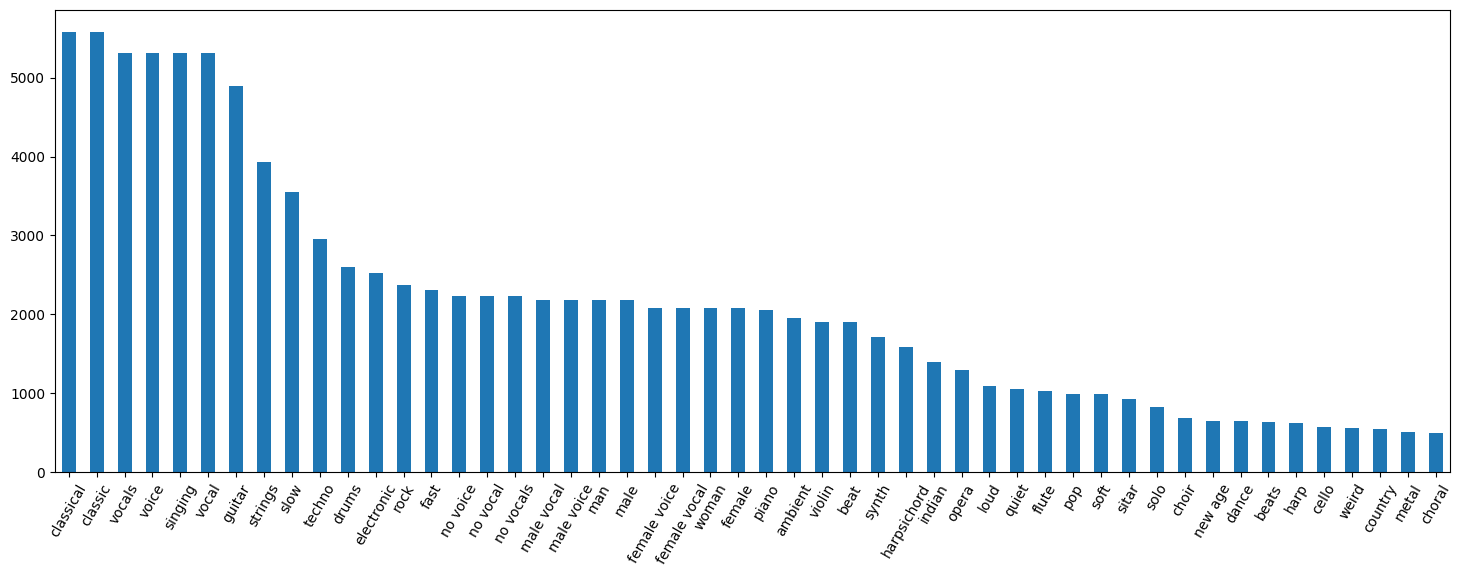

In [36]:
# plot the result again

df_updated[TAGS].sum().sort_values(ascending=False).plot.bar(figsize=(18,6), rot=60) # check data distribution in descending order

## Update split_dict, id_to_path

In [37]:
new_split_dict, new_id_to_path = get_split_dict(df_updated)

# Update Train Data's Label Using the Updated Dataframe

In [38]:
# update only train
df_only_train_updated = pd.read_csv("./annotations_final.csv", sep="\t", index_col=0)
df_only_train_updated.loc[new_split_dict['train']] = df_updated.loc[new_split_dict['train']]

## Train Conv1D model

TRAIN Epoch 00:   0%|          | 0/388 [00:00<?, ?it/s]

VALID Epoch 00: 100%|██████████| 96/96 [00:00<00:00, 327.54it/s]


[Epoch 1/10] [Train Loss: 0.6688] [Valid Loss: 0.5649]


VALID Epoch 01: 100%|██████████| 96/96 [00:00<00:00, 332.86it/s]


[Epoch 2/10] [Train Loss: 0.4966] [Valid Loss: 0.4165]


...

[Epoch 9/10] [Train Loss: 0.2895] [Valid Loss: 0.2454]


VALID Epoch 09: 100%|██████████| 96/96 [00:00<00:00, 333.94it/s]


[Epoch 10/10] [Train Loss: 0.2857] [Valid Loss: 0.2438]


TEST: 100%|██████████| 1342/1342 [00:02<00:00, 610.62it/s]


test_loss=0.47073104876564087,  roc_auc=0.6233434095669563, pr_auc=0.14188021705446616


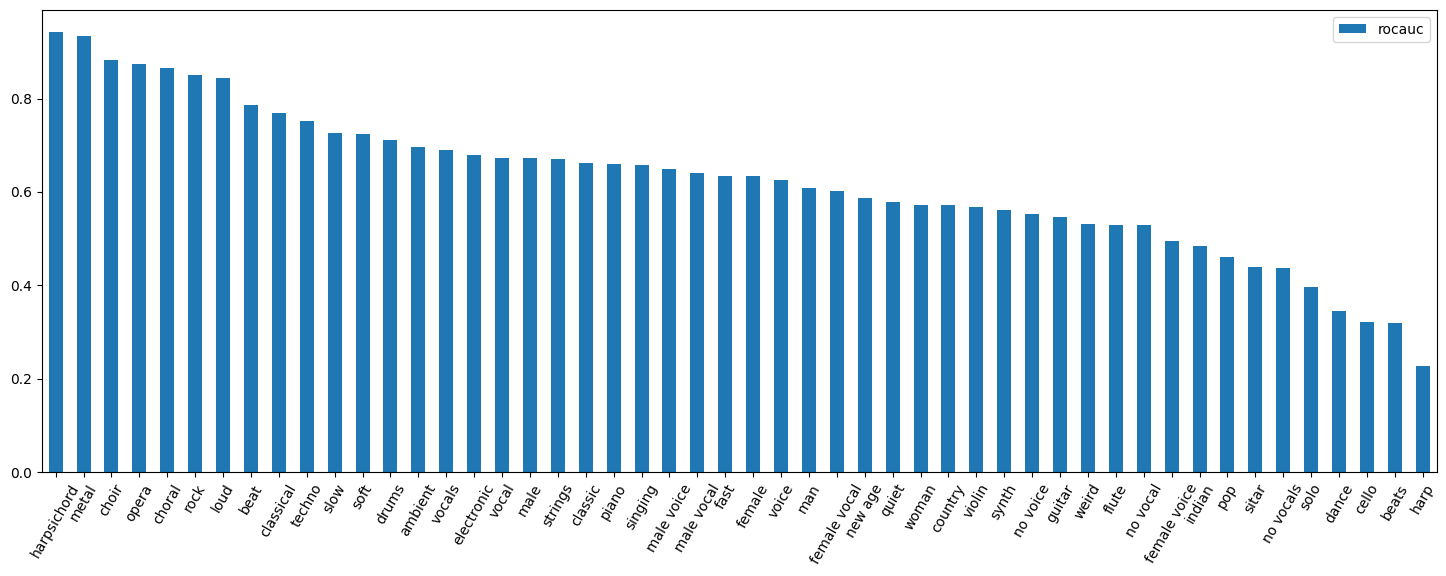

In [39]:
# Iterate over epochs.
model = Baseline()
runner = Runner(model=model, lr = LR, momentum = MOMENTUM, weight_decay = WEIGHT_DECAY, sr = SR, tags=TAGS)

conv1d_updated_processor = Processor(model, runner, df_only_train_updated, new_split_dict, new_id_to_path)
conv1d_updated_processor.run_process(num_epochs=NUM_EPOCHS)

## Train Conv2D model

TRAIN Epoch 00:   0%|          | 0/388 [00:00<?, ?it/s]

VALID Epoch 00: 100%|██████████| 96/96 [00:00<00:00, 242.94it/s]


[Epoch 1/10] [Train Loss: 0.3801] [Valid Loss: 0.2455]


VALID Epoch 01: 100%|██████████| 96/96 [00:00<00:00, 244.69it/s]


[Epoch 2/10] [Train Loss: 0.2821] [Valid Loss: 0.2328]


...

[Epoch 9/10] [Train Loss: 0.2429] [Valid Loss: 0.2104]


VALID Epoch 09: 100%|██████████| 96/96 [00:00<00:00, 242.25it/s]


[Epoch 10/10] [Train Loss: 0.2403] [Valid Loss: 0.2117]


TEST: 100%|██████████| 1342/1342 [00:02<00:00, 584.74it/s]


test_loss=0.43767984139270827,  roc_auc=0.7746130998077184, pr_auc=0.22878053649815375


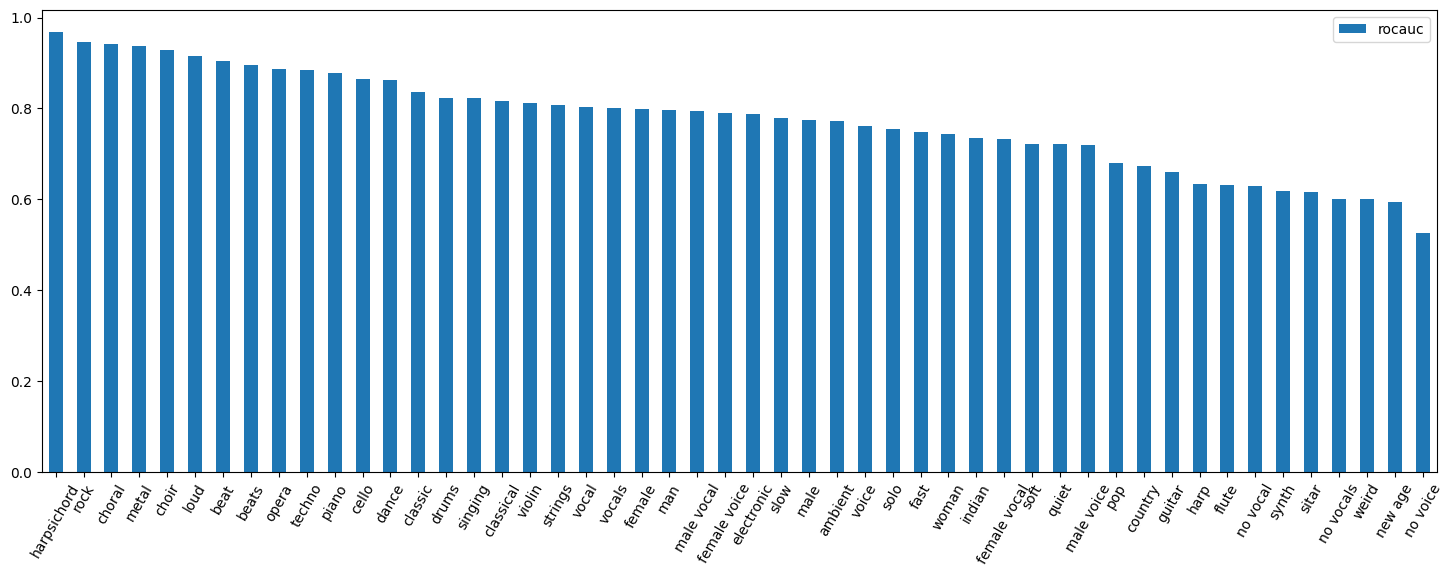

In [40]:
# Iterate over epochs.
model = CNN2D()
runner = Runner(model=model, lr = LR, momentum = MOMENTUM, weight_decay = WEIGHT_DECAY, sr = SR, tags=TAGS)

conv1d_updated_processor = Processor(model, runner, df_only_train_updated, new_split_dict, new_id_to_path)
conv1d_updated_processor.run_process(num_epochs=NUM_EPOCHS)

## HybridAttentionCNN

VALID Epoch 00: 100%|██████████| 96/96 [00:00<00:00, 97.08it/s] 


[Epoch 1/10] [Train Loss: 0.3068] [Valid Loss: 0.2247]


VALID Epoch 01: 100%|██████████| 96/96 [00:00<00:00, 96.49it/s] 


[Epoch 2/10] [Train Loss: 0.2441] [Valid Loss: 0.2116]


VALID Epoch 02: 100%|██████████| 96/96 [00:01<00:00, 95.40it/s]


...

[Epoch 9/10] [Train Loss: 0.2062] [Valid Loss: 0.1991]


VALID Epoch 09: 100%|██████████| 96/96 [00:01<00:00, 94.42it/s]


[Epoch 10/10] [Train Loss: 0.2043] [Valid Loss: 0.1958]


TEST: 100%|██████████| 1342/1342 [00:04<00:00, 296.28it/s]


test_loss=0.42620320150131796,  roc_auc=0.8301366853369643, pr_auc=0.30199100539799467


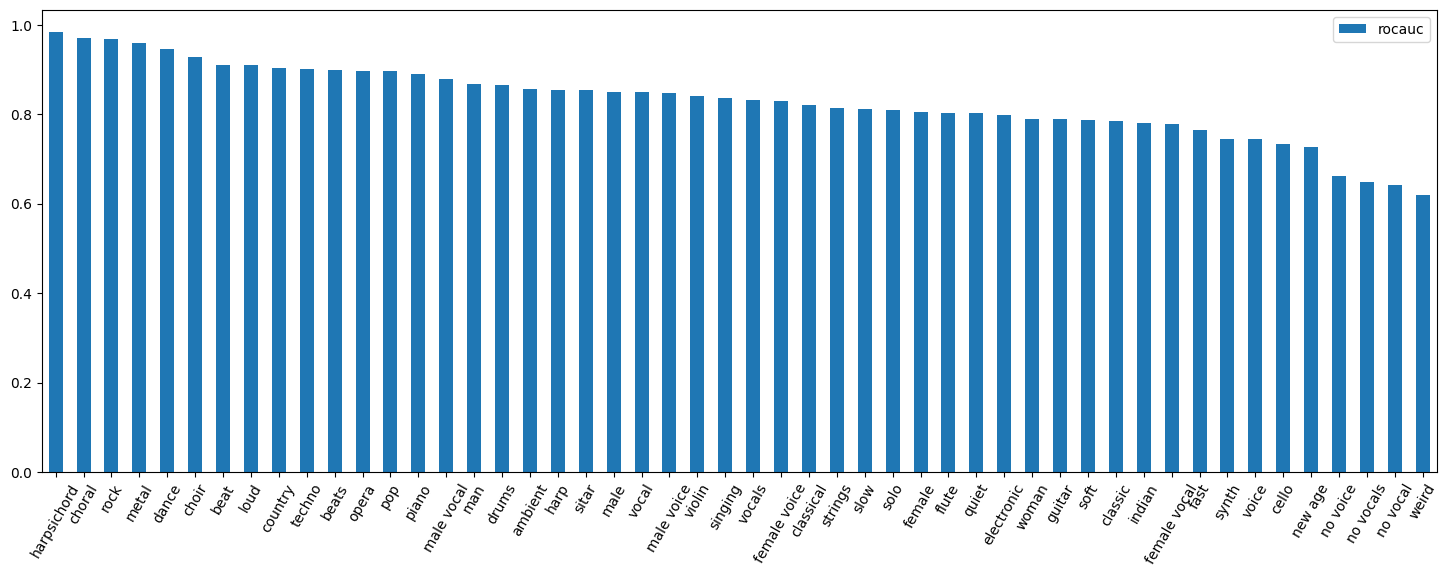

In [41]:
# Iterate over epochs.
model = HybridAttentionCNN()
runner = Runner(model=model, lr = LR, momentum = MOMENTUM, weight_decay = WEIGHT_DECAY, sr = SR, tags=TAGS)

mymodel_updated_processor = Processor(model, runner, df_only_train_updated, new_split_dict, new_id_to_path)
mymodel_updated_processor.run_process(num_epochs=NUM_EPOCHS)

# Credit
This homework was implemented and improved by Jongpil Lee, Soonbeom Choi, Taejun Kim, SeungHeon Doh, and Juhan Nam from the KAIST Music and Audio Computing Lab.
